<a href="https://colab.research.google.com/github/anarghya-04/ICSSL/blob/main/ICSSL7_Regularization_and_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import zipfile

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV

!pip install ISLP
from ISLP import load_data

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=26b74166d1da909e437b1da078e300ba387d7896211a6c258a2d4f38e0a9d9a1
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


# Utility functions

In [2]:
# Compute RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Load data

In [3]:
df = load_data('Hitters')

Now lets take a look at the data

In [4]:
print("Shape:", df.shape)
df.head() #20 columns, 322 rows - Baseball data

Shape: (322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


# Preprocessing
We need to find if there are missing values in the dataset and figure out a way to deal with them.

In [6]:
rows_with_na = df[df.isna().any(axis=1)] #check for missing values
print("\nRows containing NAs:")
rows_with_na
len(rows_with_na)


Rows containing NAs:


59

Let's drop the rows with NaN values and split the dataset into train and test.

In [11]:
df = df.dropna().reset_index(drop=True) #reset values to have less number of rows.
target = "Salary" #salary stored in y
X = df.drop(columns=[target]) #everything except salary stored in x
y = df[target]
print(X.shape, y.shape)

# First split: train+val vs test (80% / 20%), into two parts
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

# Second split: train vs validation (75% / 25% of remaining 80%)
# This gives: 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=20
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

(263, 19) (263,)
Train size: 157
Validation size: 53
Test size: 53


Now we need to transform the categorical values into numerical values and also scale all the features so that they roughly lie within the same range. If some features are represented using large numbers while others are represented in small numbers, it can skew the error calculcations, similar to what happened when we did polynomial regression.

In [8]:
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols), # Scales columns containing numerical data using (x-mu)/sigma so that the values have mean 0 and standard deviation 1
        ("cat", OneHotEncoder(drop="first"), categorical_cols) # Encodes categorical values using one hot encoding
    ]
)


In [15]:
# If you want to understand how the OneHotEncoder works, uncomment the below lines of code and try it out
X_1hot = [["East"], ["West"], ["Central"]] #Alphabetical order

# Note- The encoder sorts the list of unique categories before encoding
enc = OneHotEncoder(drop="first", sparse_output=False) #drops central
encoded = enc.fit_transform(X_1hot)

print(encoded)

[[1. 0.]
 [0. 1.]
 [0. 0.]]


# Linear regression using OLS

In [19]:
# OLS Model - pipline of preprocessing and linear model
ols_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# 2) Fit on training data
ols_model.fit(X_train_val, y_train_val)

# 3) Predictions
y_train_pred = ols_model.predict(X_train_val)
y_test_pred  = ols_model.predict(X_test)


ols_test_rmse = rmse(y_test, y_test_pred)

print("OLS Performance:")
print("Train RMSE:", rmse(y_train_val, y_train_pred))
print("Test RMSE:", rmse(y_test, y_test_pred))
print([(a,b) for a,b in zip(y_test, y_test_pred)])

OLS Performance:
Train RMSE: 306.3040695327462
Test RMSE: 309.4980873341895
[(150.0, np.float64(180.75802250703669)), (670.0, np.float64(217.68698220369612)), (277.5, np.float64(650.9950784014427)), (70.0, np.float64(236.1383875311521)), (1220.0, np.float64(670.8747584962252)), (525.0, np.float64(733.0008869175961)), (780.0, np.float64(380.9737065203134)), (1041.667, np.float64(1289.408262586643)), (230.0, np.float64(53.73211061807888)), (800.0, np.float64(810.4290255314174)), (1925.571, np.float64(1049.7176675929136)), (175.0, np.float64(158.87666031272164)), (750.0, np.float64(705.3637955285162)), (640.0, np.float64(579.5644576298929)), (160.0, np.float64(319.17782425968954)), (350.0, np.float64(219.08306030457948)), (250.0, np.float64(472.5306366992113)), (250.0, np.float64(303.4971222143284)), (550.0, np.float64(625.4032104025928)), (490.0, np.float64(263.2829053460025)), (600.0, np.float64(409.23008344057325)), (1000.0, np.float64(1081.8545409406934)), (512.5, np.float64(208.18938

[359.85914369 359.8144668  359.76491655 359.71003876 359.64935445
 359.58236247 359.5085432  359.42736335 359.33828201 359.240758
 359.13425848 359.01826867 358.89230272 358.7559152  358.60871323
 358.45036856 358.28062946 358.09933185 357.90640944 357.70190252
 357.4859653  357.25887184 357.02102041 356.77293676 356.51527601
 356.24882352 355.97449437 355.69333113 355.4064994  355.11528039
 354.82105969 354.5253118  354.2295799  353.93545104 353.6445272
 353.35839309 353.07858192 352.80654043 352.5435942  352.29091431
 352.04948586 351.82007896 351.60322247 351.39918153 351.20793987
 351.02918889 350.86232551 350.70646103 350.56044283 350.42288958
 350.29223967 350.16681079 350.0448677  349.92469413 349.80466474
 349.68331359 349.55939643 349.43194546 349.30031638 349.1642279
 349.02379448 348.87955203 348.73247559 348.58398688 348.43594888
 348.29064457 348.15073792 348.01921667 347.89931932 347.79445067
 347.70809287 347.64372027 347.60472655 347.59437222 347.61575852
 347.67183199 

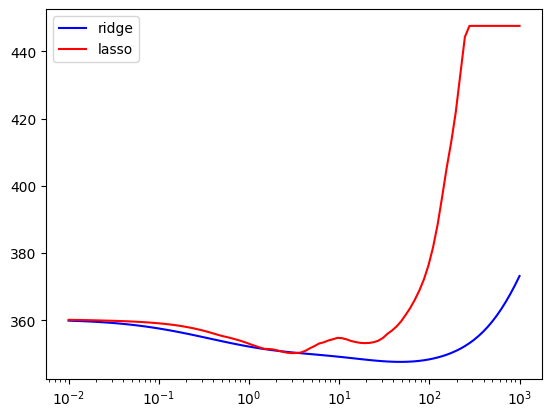

In [28]:
# Define lambdas grid
lambdas = np.logspace(-2, 3, 100)

# 5-fold CV, number of folds for cross validation.
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

ridge_val_rmse = np.full((num_folds, len(lambdas)), np.inf)
lasso_val_rmse = np.full((num_folds, len(lambdas)), np.inf)

for l_ind, l in enumerate(lambdas):
  fold = 0

  for train_idx, val_idx in kf.split(X_train_val): #splits into train and test

    X_train_fold = X_train_val.iloc[train_idx] #idx is index.
    y_train_fold = y_train_val.iloc[train_idx]
    X_val_fold   = X_train_val.iloc[val_idx]
    y_val_fold   = y_train_val.iloc[val_idx]

    # Pipeline: preprocessing + Ridge
    ridge_model = Pipeline([
            ("preprocess", preprocess),
            ("ridge", Ridge(alpha=l, max_iter=10000))
        ])

    ridge_model.fit(X_train_fold, y_train_fold)
    ridge_preds = ridge_model.predict(X_val_fold)

    ridge_val_rmse[fold, l_ind] = rmse(y_val_fold, ridge_preds)


    # Pipeline: preprocessing + Lasso
    lasso_model = Pipeline([
            ("preprocess", preprocess),
            ("lasso", Lasso(alpha=l, max_iter=100000)) #alpha is lambda
        ])

    lasso_model.fit(X_train_fold, y_train_fold)
    lasso_preds = lasso_model.predict(X_val_fold)

    lasso_val_rmse[fold, l_ind] = rmse(y_val_fold, lasso_preds)

    fold += 1

ridge_mean_rmse = np.mean(ridge_val_rmse, axis=0)

print(ridge_mean_rmse)

lasso_mean_rmse = np.mean(lasso_val_rmse, axis=0)

print(lasso_mean_rmse)

# Find best lambda
ridge_best_lambda = lambdas[np.argmin(ridge_mean_rmse)]
print("Best lambda for ridge:", ridge_best_lambda)
print("Best Validation RMSE for ridge:", min(ridge_mean_rmse))

lasso_best_lambda = lambdas[np.argmin(lasso_mean_rmse)]
print("Best lambda for lasso:", lasso_best_lambda)
print("Best Validation RMSE for lasso:", min(lasso_mean_rmse))

# Plot the lambdas vs mean_rmse for ridge and lasso
plt.figure()
plt.plot(lambdas, ridge_mean_rmse, c="b", label="ridge")
plt.plot(lambdas, lasso_mean_rmse, c="r", label="lasso")

plt.xscale('log')
plt.legend()


# Fit the final model
Now that we have the best lambda values, we can try to fit the whole train+val dataset using these values.

In [29]:
ridge_final_model = Pipeline([
    ("preprocess", preprocess),
    ("ridge", Ridge(alpha=ridge_best_lambda))
])

ridge_final_model.fit(X_train_val, y_train_val)

ridge_test_preds = ridge_final_model.predict(X_test)

lasso_model_final_model = Pipeline([
    ("preprocess", preprocess),
    ("lasso", Lasso(alpha=lasso_best_lambda))
])

lasso_final_model.fit(X_train_val, y_train_val)

lasso_test_preds = lasso_final_model.predict(X_test)

print("Test RMSE for OLS:", ols_test_rmse)
print("Test RMSE for Ridge Regression with cross validation:", rmse(y_test, ridge_test_preds))
print("Test RMSE for Lasso Regression with cross validation:", rmse(y_test, lasso_test_preds))

NameError: name 'lasso_final_model' is not defined